# LightGBM and CatBoost

## LightGBM
Implementation of Gradient Boosting designed to handle large datasets and high-dimantional data with speed and accuracy

Key Features of LightGBM
- **Histogram-Based Spilliting:** it uses histogram to discretize continuous features, reducing memory usuage and computation
- **Leaf-Wise Tree Growth:** Grows the tree by adding splits to the leaf with highest loss, imroving efficiency but potentially overfitting if not regularized
- **Support for GPU Training:** Accelerate training using GPU Computation
  
- **Handling Sparce Data:** Efficiently handles sparse dataset with missing or sparse values


### Advantage 
- Faster traininig than XGBoost
- Handles large datasets effectively
- Reduces memoty usuage with histogram-based spilliting

### When to Use LightGBM
- When you have large datasets with numerical features
- Timesensitive task requires fas training
---

## Overview of CatBoost
Gradient Boosting Library developed specifically to handle categorical features without the need for preprocessing like one-hot encoding

- ### Key Features of CatBoost
  -  Native support for Categorical Data
     - Uses statistical encoding for categorical features
   - Ordered Boosting
     - Uses permutation based scheme to train model 
   - Robust to Overfitting
     - Implements build-in regularization methods and thats why no overfitting most of the time
 - ### Advantages
   - Eliminates the need for manual encoding of categorical data
   - Reduces overfitting with robust boosting technique
   - Easy to implement for datasets with many categorical features
 - ### When to Use CatBoost
   - Datasets with high proportion of categorical features
   - Application where overfitting is a concern
  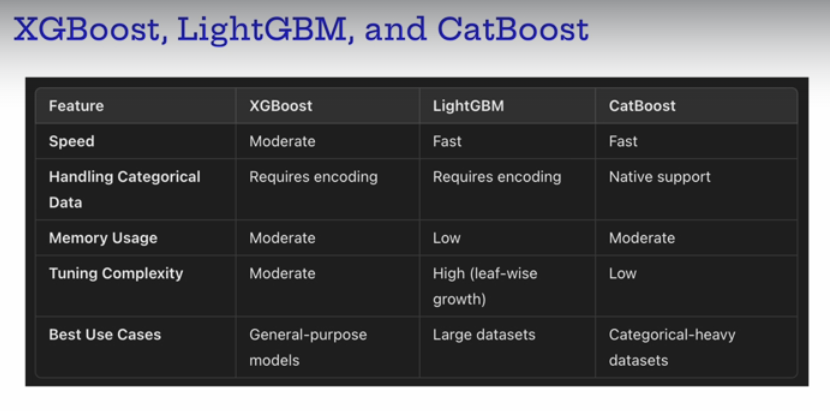

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Load Titanic Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [20]:
# Selection features and target
features = ['Pclass','Sex','Age','Fare','Embarked']
target = 'Survived'


In [21]:

# Handle missing values
df.fillna({'Age':df['Age'].median()},inplace=True)
df.fillna({'Embarked':df['Embarked'].mode()[0]},inplace=True)

In [22]:
# Encode CATEGORICAL vARIABLE
label_encoders = {}
for col in ['Sex','Embarked']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    
print(label_encoders)

{'Sex': LabelEncoder(), 'Embarked': LabelEncoder()}


In [23]:
# Split Data
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(f"Training Data Shape:{X_train.shape}")
print(f"Test Data Shape:{X_test.shape}")

Training Data Shape:(712, 5)
Test Data Shape:(179, 5)


In [25]:
# Train LightGBM model
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000663 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 180
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [30]:
# Predict and Evaluate
lgb_pred = lgb_model.predict(X_test)
print(f"LightGBM Accuracy: {accuracy_score(y_test, lgb_pred):.4f}")

LightGBM Accuracy: 0.8045


In [38]:
# Train CatBoost Model
cat_features = ['Pclass','Sex','Embarked']
cat_model =  CatBoostClassifier(cat_features = cat_features, verbose=0)
cat_model.fit(X_train, y_train)

In [40]:
# Predict and Evaluate
cat_pred = cat_model.predict(X_test)
print(f"Catboost Accuracy:, {accuracy_score(y_test, cat_pred):.4f}")

Catboost Accuracy:, 0.8156


In [43]:
# Train XGBoost model
xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [47]:
# Predict and evaluate
xgb_pred = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")

XGBoost Accuracy: 0.7709


---

### Train Catboost Without encoding categorical features

In [50]:
cat_model_native = CatBoostClassifier(cat_features=['Sex','Embarked'], verbose=0)
cat_model_native.fit(X_train, y_train)

In [49]:
# PRED AND Evaluate
cat_preds_native=cat_model_native.predict(X_test)
print(f"CatBoost Native Accuracy: {accuracy_score(y_test,cat_preds_native):.4f}")

CatBoost Native Accuracy: 0.8156
